# Jaw Keypoint Prediction

Set `VIDEO_PATH` and `OUTPUT_DIR` below. Uses the **shared** checkpoint at `../Training/checkpoints/best_model.pt`.

Writes dataset-style CSVs to `OUTPUT_DIR`:
- `jaw_tip.csv` — `frame,x,y`
- `jaw_base.csv` — `frame,x,y` (jaw line / base keypoint)

Coordinates are in the source video's pixel space. Frame numbers are 0-based video frame indices.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path("utils.py").resolve().parent))
from utils import run_inference_on_video, default_checkpoint_path

# ── Configuration ──────────────────────────────────────────────────────────
VIDEO_PATH = "/mnt/c/Users/wanglab/Desktop/Ina/IRt_TeLC/IRt_TeLC_08/IRt_TeLC_08_Pre/IRt_TeLC_08_2026_0331_pre_side_view.mp4"
OUTPUT_DIR = "/mnt/c/Users/wanglab/Desktop/Ina/IRt_TeLC/IRt_TeLC_08/IRt_TeLC_08_Pre/predictions"
BATCH_SIZE = 32

CHECKPOINT = default_checkpoint_path()
print(f"Checkpoint: {CHECKPOINT}")

Checkpoint: ../Training/checkpoints/best_model.pt


In [2]:
df, tip_csv, base_csv = run_inference_on_video(
    video_path=VIDEO_PATH,
    output_dir=OUTPUT_DIR,
    checkpoint_path=CHECKPOINT,
    batch_size=BATCH_SIZE,
)
df.head()

Loaded shared multi-condition model from ../Training/checkpoints/best_model.pt
Video: /mnt/c/Users/wanglab/Desktop/Ina/IRt_TeLC/IRt_TeLC_08/IRt_TeLC_08_Pre/IRt_TeLC_08_2026_0331_pre_side_view.mp4
Frames: 398,477
Source size: 640x480
Model input: 320x240
Checkpoint: ../Training/checkpoints/best_model.pt


Video chunks: 100%|██████████| 779/779 [2:29:27<00:00, 11.51s/chunk]  


Wrote /mnt/c/Users/wanglab/Desktop/Ina/IRt_TeLC/IRt_TeLC_08/IRt_TeLC_08_Pre/predictions/jaw_tip.csv
Wrote /mnt/c/Users/wanglab/Desktop/Ina/IRt_TeLC/IRt_TeLC_08/IRt_TeLC_08_Pre/predictions/jaw_base.csv


,frame,tip_x,tip_y,line_x,line_y
0,0,442.044006,259.214081,575.245239,279.581299
1,1,440.248108,259.942139,575.166931,281.263885
2,2,440.190796,260.766022,573.589600,282.696228
3,3,440.891968,260.285553,575.560059,282.695709
4,4,441.996216,259.827576,575.042969,282.356598


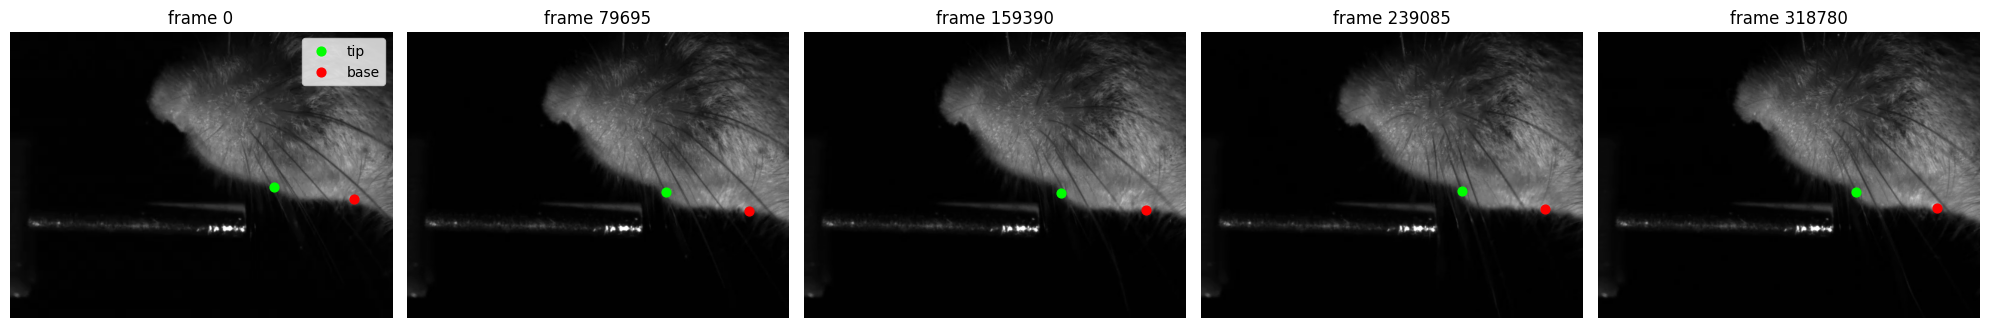

In [3]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd

# Overlay predictions on a few sample frames from the video
cap = cv2.VideoCapture(VIDEO_PATH)
sample_frames = df["frame"].iloc[:: max(1, len(df) // 5)][:5].astype(int)

fig, axes = plt.subplots(1, len(sample_frames), figsize=(4 * len(sample_frames), 4))
if len(sample_frames) == 1:
    axes = [axes]

tip_df = pd.read_csv(tip_csv)
base_df = pd.read_csv(base_csv)

for ax, fr in zip(axes, sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fr))
    ret, bgr = cap.read()
    ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    tip = tip_df.loc[tip_df["frame"] == fr].iloc[0]
    base = base_df.loc[base_df["frame"] == fr].iloc[0]
    ax.scatter(tip["x"], tip["y"], c="lime", s=40, label="tip")
    ax.scatter(base["x"], base["y"], c="red", s=40, label="base")
    ax.set_title(f"frame {fr}")
    ax.axis("off")

cap.release()
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()